# Supervisior-Worker - 계산 가능한 웹 검색 에이전트

https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/#2-create-supervisor-with-langgraph-supervisor

In [1]:
from dotenv import load_dotenv
import os
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('../env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
MODEL_API_VERSION=os.getenv('MODEL_API_VERSION')
if MODEL_API_VERSION:
    os.environ['MODEL_API_VERSION'] = MODEL_API_VERSION
if AZURE_OPENAI_API_KEY:
    print(AZURE_OPENAI_API_KEY[:10])
else:
    print("AZURE_OPENAI_API_KEY가 설정되지 않았습니다.")
print(MODEL_NAME, MODEL_API_VERSION)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

langsmith_key = os.getenv('LANGSMITH_API_KEY')
if langsmith_key:
    os.environ['LANGCHAIN_API_KEY'] = langsmith_key
ep = os.getenv('LANGCHAIN_ENDPOINT')
if ep:
    os.environ['LANGCHAIN_ENDPOINT'] = ep
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'AGENT'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    _lk = os.getenv('LANGSMITH_API_KEY')
    if _lk and len(_lk) > 0:
        print('랭스미스로 추적 중입니다 :', _lk[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

3BHTZdVIXx
gpt-5-nano 2025-01-01-preview


In [2]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,
    azure_deployment=MODEL_NAME,
    api_version=os.environ.get('MODEL_API_VERSION', '2024-12-01-preview'),
    model = MODEL_NAME,
)

In [3]:
# %pip install langchain-tavily

In [4]:
from langchain_tavily import TavilySearch

tavily_api_key = os.getenv('TAVILY_API_KEY')
print(tavily_api_key[:10])
web_search = TavilySearch(max_results=5, api_key=tavily_api_key)

tvly-dev-7


In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware

web_search_agent = create_agent(
    model=llm,
    tools=[web_search],
    # middleware=[ToolCallLimitMiddleware(thread_limit=4, run_limit=2)],
    system_prompt=("""
        당신은 슈버바이저의 지시를 받아 검색하는 웹 서칭 에이전트입니다.
        지침:
        - 오직 정보를 찾는 것과 관련된 작업만 도와야 합니다.
        - 작업을 마친 후에는 바로 슈퍼바이저에게 응답하십시오.
        - 작업 결과만 응답하고, 그 외의 다른 텍스트는 절대 포함하지 마십시오."""
    ),
    name = "web_search_agent", #supervisor의 하위 에이전트는 반드시 이름을 지정해야 합니다.
    debug=True,
)

In [6]:
import calc_tools as ct

CALC_TOOLS = [ct.add, ct.subtract, ct.multiply, ct.divide, ct.square, ct.square_root]

math_agent = create_agent(
    model=llm,
    tools=CALC_TOOLS,
    system_prompt=("""
        당신은 수학 에이전트입니다.

        지침:
        - 오직 수학과 관련된 작업만 도와야 합니다.
        - 작업을 마친 후에는 바로 슈퍼바이저에게 응답하십시오.
        - 작업 결과만 응답하고, 그 외의 다른 텍스트는 절대 포함하지 마십시오."""
    ),
    name = "math_agent",
    debug=True,
)

In [ ]:
import file_tools as ft

FILE_TOOLS = [ft.save_file, ft.read_file, ft.list_data_files, ft.delete_file]

file_agent = create_agent(
    model=llm,
    tools=FILE_TOOLS,
    # middleware=[ToolCallLimitMiddleware(run_limit=2, thread_limit=4)], #한 번의 사용자 질문(Run), 한 번의 사용자 대화(thread)에서 호출할 수 있는 최대 횟수
    system_prompt=("""
        당신은 파일 관리 에이전트입니다.

        지침:
        - 오직 파일 관리와 관련된 작업만 도와야 합니다.
        - 파일을 생성할 때에는 기존의 파일을 덮어쓰지 않고 뒤에 숫자나 다른 문자를 붙여 생성합니다.
        - 생성하는 파일명은 항상 영어로 작성하고 파일의 이름으로 내용을 대략 유추할 수 있는 간단한 이름을 붙입니다.
        - 파일을 읽을 때에는 폴더 내의 파일 목록을 출력하고, 파일 목록에서 가정 적절한 파일 이름을 선택하여 읽습니다.
        - 작업을 마친 후에는 바로 슈퍼바이저에게 응답하십시오.
        - 작업 결과만 응답하고, 그 외의 다른 텍스트는 절대 포함하지 마십시오."""
    ),
    name = "file_agent",
    debug=True,
)

In [ ]:
from typing import Annotated, Literal, Optional, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import MemorySaver

def add_iteration(x: int, _: int) -> int:
    if type(x) == int:
        return x + 1
    else:
        return 0

class State(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    next: Optional[str]
    iteration: Annotated[int, add_iteration]
    config: Optional[dict]
    last_decision: Optional[dict]  # 에이전트 간 통신용, 메시지 본문 대신 State에만 저장 → 직렬화 경고 방지

class SupervisorDecision(BaseModel):
    next: Literal["web_search_agent", "math_agent", "file_agent", "FINISH"] = Field(..., description="다음으로 실행할 에이전트 또는 FINISH")
    task: str = Field(default="", description="하위 에이전트에게 전달할 작업 지시")
    final_answer: str = Field(default="", description="FINISH일 때 사용자에게 전달할 최종 답변")

SUPERVISOR_PROMPT = """당신은 세 개의 하위 에이전트를 관리하는 슈퍼바이저입니다.
- web_search_agent: 웹 검색이 필요할 때 할당
- math_agent: 수학/계산이 필요할 때 할당
- file_agent: 파일 검색/생성/읽기/삭제 등 파일 작업이 필요할 때 할당

규칙:
- 한 번에 하나의 에이전트만 선택하세요.
- 충분한 정보가 모이면 FINISH를 선택하세요.
- FINISH가 아니면 task를 구체적으로 작성하세요.
- FINISH면 final_answer를 작성하세요.
"""

supervisor_llm = llm.with_structured_output(SupervisorDecision, method="function_calling")
def supervisor_node(state: State) -> dict:
    msgs = state["messages"]
    
    # iteration = state.get("iteration", 0)
    # iter_prompt = f"iteration: {iteration}\n 반복 iteration이 2이상이 되면 최종 답변을 출력하는 FINISH를 선택하세요."
    # decision = supervisor_llm.invoke([SystemMessage(content=SUPERVISOR_PROMPT + iter_prompt)] + msgs)
    
    decision = supervisor_llm.invoke([SystemMessage(content=SUPERVISOR_PROMPT)] + msgs)
    
    d = decision.model_dump(mode='json') 
    
    next_node = "__end__" if d["next"] == "FINISH" else d["next"]
    print(f">>> iteration: {state['iteration']}, next_node: {next_node}")

    if next_node == "__end__":
        final_ans = d.get("final_answer", "요청을 종료합니다.")
        return {
            "messages": [AIMessage(content=final_ans)], 
            "next": "__end__", 
            "last_decision": None
        }

    return {
        "messages": [HumanMessage(content=d["task"])],
        "next": next_node,
        "iteration": None,
        "last_decision": d
    }

def _get_config(state: State) -> dict:
    """state에 들어온 config를 반환"""
    cfg = state.get("config")
    if cfg is not None:
        return cfg
    return {"configurable": {"thread_id": "default"}}

def web_search_node(state: State) -> dict:
    cfg = _get_config(state)
    out = web_search_agent.invoke({"messages": state["messages"]}, config=cfg)
    new = out.get("messages", [])[len(state["messages"]):] if isinstance(out, dict) else []
    return {"messages": new, "next": "supervisor"}

def math_node(state: State) -> dict:
    cfg = _get_config(state)
    out = math_agent.invoke({"messages": state["messages"]}, config=cfg)
    new = out.get("messages", [])[len(state["messages"]):] if isinstance(out, dict) else []
    return {"messages": new, "next": "supervisor"}

def file_node(state: State) -> dict:
    cfg = _get_config(state)
    out = file_agent.invoke({"messages": state["messages"]}, config=cfg)
    new = out.get("messages", [])[len(state["messages"]):] if isinstance(out, dict) else []
    return {"messages": new, "next": "supervisor"}

def route_after_supervisor(state: State) -> Literal["web_search_agent", "math_agent", "file_agent", "__end__"]:
    n = state.get("next") or "__end__"
    if n == "supervisor":
        return "__end__"
    if n == "web_search_agent":
        return "web_search_agent"
    if n == "math_agent":
        return "math_agent"
    if n == "file_agent":
        return "file_agent"
    # if state.get("iteration", 0) >= 3:
    #     return "__end__"
    return "__end__"

# 그래프 구성
builder = StateGraph(State)
builder.add_node("supervisor", supervisor_node)
builder.add_node("web_search_agent", web_search_node)
builder.add_node("math_agent", math_node)
builder.add_node("file_agent", file_node)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", route_after_supervisor, {
    "web_search_agent": "web_search_agent",
    "math_agent": "math_agent",
    "file_agent": "file_agent",
    "__end__": END,
})
builder.add_edge("web_search_agent", "supervisor")
builder.add_edge("math_agent", "supervisor")
builder.add_edge("file_agent", "supervisor")

supervisor = builder.compile(checkpointer=MemorySaver())
supervisor

In [ ]:
input_data = {
    "messages": [
        {
            "role": "user",
            "content": "한국과 미국 지난해 총 경제 규모의 차이를 알려줘.",
        }
    ]
}

result = supervisor.invoke(input_data, config={"configurable": {"thread_id": "user-1"}}, mode = 'update')
print(result['messages'][-1].pretty_repr(html=True))

In [14]:
input_data = {
    "messages": [
        {
            "role": "user",
            "content": "영어 인사말이 적힌 간단한 text 파일을 하나 생성해줘",
        }
    ]
}

result = supervisor.invoke(input_data, config={"configurable": {"thread_id": "user-2"}}, mode = 'update')
print(result['messages'][-1].pretty_repr(html=True))

>>> iteration: 0, next_node: file_agent
[values] {'messages': [HumanMessage(content='영어 인사말이 적힌 간단한 text 파일을 하나 생성해줘', additional_kwargs={}, response_metadata={}, id='0d8a734b-ccc3-4403-80aa-3ac3224eadc5'), HumanMessage(content='Create a simple text file named greetings.txt containing common English greetings, one per line. Include the lines: Hello, Hi, Hey there, Greetings, Howdy, Welcome, Good morning, Good afternoon, Good evening. Save the file and return its path.', additional_kwargs={}, response_metadata={}, id='96a30ca7-44e3-4966-997f-7fc8d2b30617')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1109, 'prompt_tokens': 517, 'total_tokens': 1626, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1088, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 

In [ ]:
input_data = {
    "messages": [
        {
            "role": "user",
            "content": "아까 내가 생성한 파일 삭제해줘",
        }
    ]
}

result = supervisor.invoke(input_data, config={"configurable": {"thread_id": "user-2"}}, mode = 'update')
print(result['messages'][-1].pretty_repr(html=True))

In [ ]:
# %pip install langgraph-supervisor

In [17]:
from langgraph_supervisor import create_supervisor
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

supervisor = create_supervisor(
    model=llm,
    name = "supervisor",
    agents=[web_search_agent, math_agent, file_agent],
    system_prompt=("""
        당신은 여러 에이전트를 관리하는 슈퍼바이저입니다:
        - web_search_agent: 웹 서칭과 관련된 작업을 이 에이전트에게 할당하십시오.
        - math_agent: 수학과 관련된 작업을 이 에이전트에게 할당하십시오.
        - file_agent: 파일 검색, 생성, 삭제, 읽기 등 파일에 대한 작업이 필요할 때 이 에이전트에게 할당하세요.

        작업은 반드시 한 번에 하나의 에이전트에게만 할당하고, 병렬로 호출하지 마십시오.
        중간 결과를 저장하고 최종 결과를 출력할 때 중간 결과에 의미 있는 내용이 있다면 정리하여 포함하시오.
        서브 에이전트가 할 수 있는 작업을 직접 수행하지 마십시오.
        추가 질문을 하지말고 스스로 판단해서 최종 답변을 출력하고 완료하세요."""
    ),
    add_handoff_back_messages=True, # 에이전트가 작업을 완료한 후, 슈퍼바이저에게 응답을 보내는 것을 활성화합니다.
    output_mode="full_history", # 슈퍼바이저의 응답을 전체 메시지 히스토리로 설정합니다.
).compile(checkpointer=memory, debug=False)

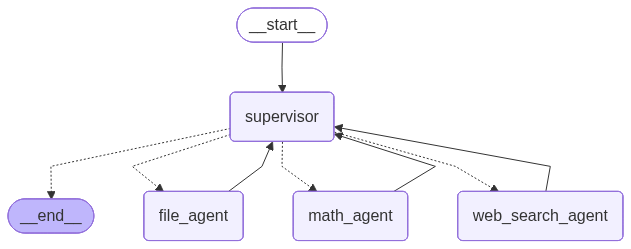

In [18]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [19]:
input_data = {
    "messages": [
        {
            "role": "user",
            "content": "한국과 미국 2025년 총 GDP 규모 차이를 알려줘.",
        }
    ]
}

result = supervisor.invoke(input_data, mode = 'update', config={"configurable": {"thread_id": "user-2"}})
print(result['messages'][-1].pretty_repr(html=True))

[values] {'messages': [HumanMessage(content='한국과 미국 2025년 총 GDP 규모 차이를 알려줘.', additional_kwargs={}, response_metadata={}, id='5e2c68f8-b7e4-4fca-ad20-0c2b98b94e4c'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 343, 'prompt_tokens': 178, 'total_tokens': 521, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DCrLLQRc9F9sf4xAb9ILZOlcZNeEB', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severit

In [20]:
input_data = {
    "messages": [
        {
            "role": "user",
            "content": "한국과 미국, 일본의 총 GDP를 2020년부터 지금까지 조사해서 csv 형식의 파일로 저장해줘.",
        }
    ]
}

result = supervisor.invoke(input_data, mode = 'update', config={"configurable": {"thread_id": "user-2"}})
print(result['messages'][-1].pretty_repr(html=True))

[values] {'messages': [HumanMessage(content='한국과 미국 2025년 총 GDP 규모 차이를 알려줘.', additional_kwargs={}, response_metadata={}, id='5e2c68f8-b7e4-4fca-ad20-0c2b98b94e4c'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 343, 'prompt_tokens': 178, 'total_tokens': 521, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DCrLLQRc9F9sf4xAb9ILZOlcZNeEB', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severit

In [21]:
input_data = {
    "messages": [
        {
            "role": "user",
            "content": "방금 만든 파일을 삭제해",
        }
    ]
}

result = supervisor.invoke(input_data, mode = 'update', config={"configurable": {"thread_id": "user-2"}})
print(result['messages'][-1].pretty_repr(html=True))

================================== Ai Message ==================================
Name: supervisor

직접 파일 시스템에 접근할 수 없어서 제가 파일을 대신 삭제해 드릴 수는 없어요. 다만 사용 환경에 맞춘 삭제 방법을 안내해 드립니다.

삭제할 파일명: gdp_usa_jpn_kor_2020_2025.csv

- Linux / macOS 터미널
  - 현재 디렉토리에 있을 때:
    rm gdp_usa_jpn_kor_2020_2025.csv
  - 필요 시 강제 삭제:
    rm -f gdp_usa_jpn_kor_2020_2025.csv
  - 삭제 확인:
    ls -l gdp_usa_jpn_kor_2020_2025.csv

- Windows 명령 프롬프트 (cmd)
  - del gdp_usa_jpn_kor_2020_2025.csv

- Windows PowerShell
  - Remove-Item .\gdp_usa_jpn_kor_2020_2025.csv

- Python에서 삭제
  - import os
    os.remove('gdp_usa_jpn_kor_2020_2025.csv')

원하시면 특정 환경에 맞춘 스크립트나 한 번에 확인까지 포함한 삭제 스크립트를 작성해 드릴게요. 어떤 환경에서 삭제하실지 알려주시면 더 정확하게 도와드리겠습니다.


In [22]:
input_data = {
    "messages": [
        {
            "role": "user",
            "content": "남한과 북한의 인구수의 합은? 언제 기준 데이터인지 명시해",
        }
    ]
}

result = supervisor.invoke(input_data, config={"configurable": {"thread_id": "user-2"}})
print(result['messages'][-1].pretty_repr(html=True))

[values] {'messages': [HumanMessage(content='한국과 미국 2025년 총 GDP 규모 차이를 알려줘.', additional_kwargs={}, response_metadata={}, id='5e2c68f8-b7e4-4fca-ad20-0c2b98b94e4c'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 343, 'prompt_tokens': 178, 'total_tokens': 521, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DCrLLQRc9F9sf4xAb9ILZOlcZNeEB', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severit